### Exercise 5.1

<br>

1) Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe with respect to the column names and the variable types.

2) Pick data from the following columns to a second dataframe `df2`: `y`, `job`, `marital`, `default`, `housing`, `poutcome`.

3) Convert categorical variables to dummy numerical values using the command

`df3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])`

4) Produce a heat map of correlation coefficients for all variables in `df3`. Describe the amount of correlation between the variables in your own words.

5) Select the column called `y` of `df3` as the target variable `y`, and all the remaining columns for the explanatory variables `X`.

6) Split the dataset into training and testing sets with 75/25  ratio.

7) Setup a logistic regression model, train it with training data and predict on testing data.

8) Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.


### Exercise 5.2

Consider the data from CSV file `weight-height.csv`.

1) Read data into a pandas dataframe.

2) Pick the target variable `y` as weight in kilograms, and the feature variable `X` as height in centimeters.

3) Split the data into training and testing sets with 80/20 ratio.

4) Scale the training and testing data using normalization and standardization.

5) Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# Excercise5.1
#1.Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe
#with respect to the column names and the variable types.

In [7]:

df = pd.read_csv("bank.csv", sep=';')
print(df.head())
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nDataFrame Info:")
print(df.info())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'co

In [ ]:
#2.Pick data from the following columns to a second dataframe df2: y, job, marital, default, housing, poutcome.

In [11]:
df2 = df[['y', 'job', 'marital', 'default', 'housing', 'poutcome']]
print(df2.head())

    y          job  marital default housing poutcome
0  no   unemployed  married      no      no  unknown
1  no     services  married      no     yes  failure
2  no   management   single      no     yes  failure
3  no   management  married      no     yes  unknown
4  no  blue-collar  married      no     yes  unknown


In [ ]:
#3.Convert categorical variables to dummy numerical values using the commanddf3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])

In [14]:
df3 = pd.get_dummies(
    df2,
    columns=['job', 'marital', 'default', 'housing', 'poutcome']
)

print(df3.head())

    y  job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  \
0  no       False            False             False          False   
1  no       False            False             False          False   
2  no       False            False             False          False   
3  no       False            False             False          False   
4  no       False             True             False          False   

   job_management  job_retired  job_self-employed  job_services  job_student  \
0           False        False              False         False        False   
1           False        False              False          True        False   
2            True        False              False         False        False   
3            True        False              False         False        False   
4           False        False              False         False        False   

   ...  marital_married  marital_single  default_no  default_yes  housing_no  \
0  ...      

In [ ]:
#4.Produce a heat map of correlation coefficients for all variables in df3.Describe the amount of correlationbetween the variables in your own words.

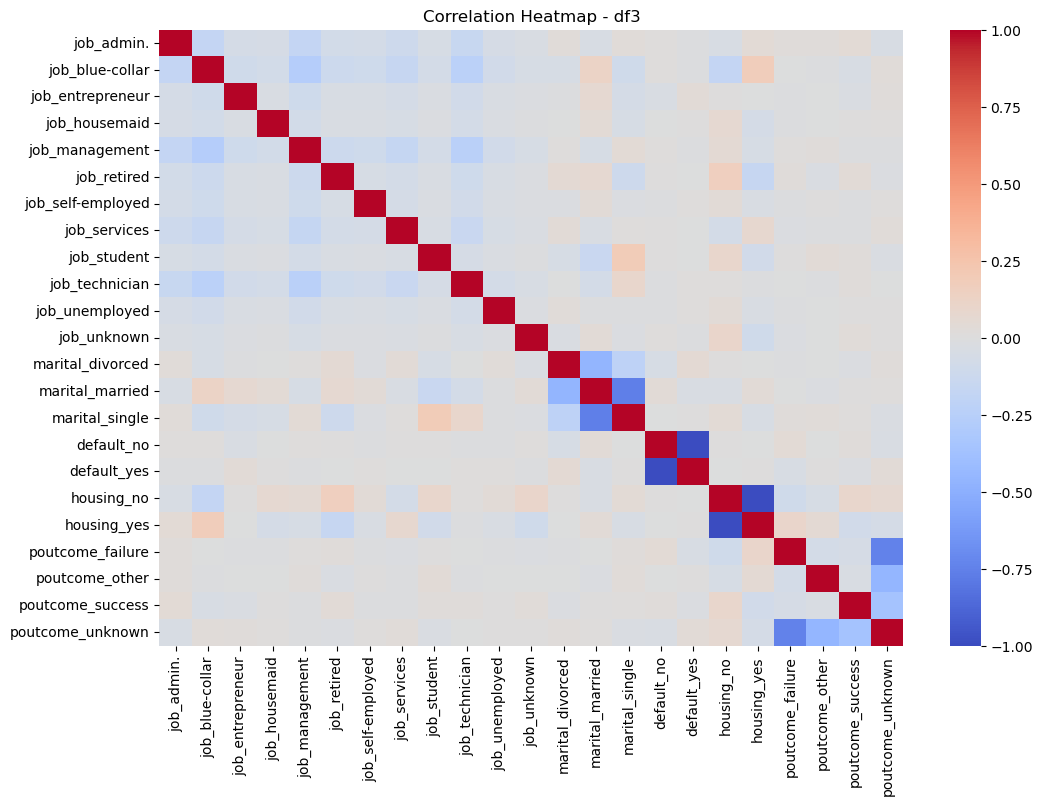

In [19]:
corr = df3.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap - df3")
plt.show()


In [ ]:
Most variables show very weak or near-zero correlation, represented by light blue and neutral colors in the heatmap. This means that most features do not have a strong linear relationship with each other and are largely independent.

In [ ]:
#5.Select the column called y of df3 as the target variable y,and all the remaining columns for the explanatory variables X.

In [20]:
y = df3['y']
X = df3.drop(columns=['y'])

In [ ]:
#6Split the dataset into training and testing sets with 75/25 ratio.

In [21]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
#7.Setup a logistic regression model, train it with training data and predict on testing data.

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
#8.Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.

Confusion matrix:
[[997   9]
 [106  19]]
Accuracy: 0.8983200707338639


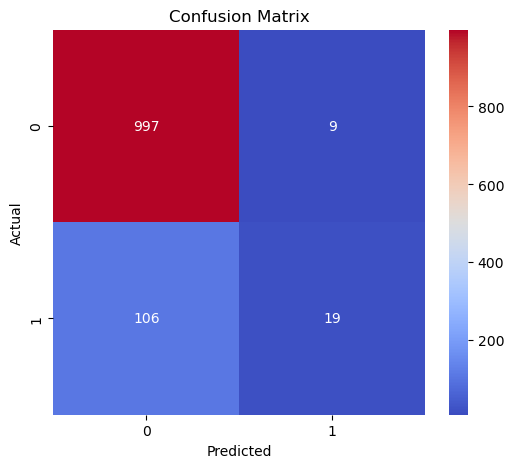

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Confusion matrix:")
print(cm)
print("Accuracy:", acc)

# Heatmap of confusion matrix (optional)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#Exercise 5.2
#Consider the data from CSV file weight-height.csv.
#Read data into a pandas dataframe

In [25]:

df = pd.read_csv("weight-height.csv")
print(df)

      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [ ]:
#2.Pick the target variable y as weight in kilograms, and the feature variable X as height in centimeters.

In [31]:
from sklearn.model_selection import train_test_split
X = df['Height']
y = df['Weight']

In [32]:
#3.Split the data into training and testing sets with 80/20 ratio.

In [33]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
#4.Scale the training and testing data using normalization and standardization.

In [35]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

norm_scaler = MinMaxScaler()
X_train_norm = norm_scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test_norm = norm_scaler.transform(X_test.values.reshape(-1, 1))
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test_std = std_scaler.transform(X_test.values.reshape(-1, 1))

In [36]:
#5. Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value

In [39]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train.values.reshape(-1, 1), y_train)  
y_pred = knn.predict(X_test.values.reshape(-1, 1))
r2 = r2_score(y_test, y_pred)
print(" KNN Regression Performance (k=5)")
print("R² value:", r2)

 KNN Regression Performance (k=5)
R² value: 0.8346485438169171
